Imports

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

Import Dataset

In [7]:
df = pd.read_csv("data.csv", delimiter='\t', low_memory=False)
df.head()

,Unnamed: 0,date,id,size_grp,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,...,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d,ret,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129
0,53170,9/30/1962,33814,mega,-0.4108911,0.3436155,0.0,-0.290922,-0.44744524,0.24796748,...,0.27476254,0.0,0.17842606,0.033875,0.0,0.017612524,NaN,NaN,NaN,NaN
1,53907,10/31/1962,33814,mega,-0.41374046,0.33333334,0.0,-0.281893,-0.44759825,0.23134328,...,0.21059783,0.0,0.13586956,0.094301,0.0,0.1242307722568512,NaN,NaN,NaN,NaN
2,54659,11/30/1962,33814,mega,-0.4017857,0.33169705,0.0,-0.297587,-0.4487909,0.2214854,...,0.1679947,0.0,0.1374502,0.111406,0.0,-0.01208981,NaN,NaN,NaN,NaN
3,55425,12/31/1962,33814,mega,-0.37068966,0.32225236,0.0,-0.309585,-0.4398085,0.21501926,...,0.12516046,0.0,0.1097561,0.194480,0.11369509,0.087412588,NaN,NaN,NaN,NaN
4,56207,1/31/1963,33814,mega,-0.36795145,0.32456142,0.0,-0.308729,-0.44189188,0.21082802,...,0.035714287,0.0,0.10841837,0.149682,0.08151476,-0.021864953,NaN,NaN,NaN,NaN


Clean Dataset

In [8]:
df.drop(columns=['Unnamed: 126', 'Unnamed: 127', 'Unnamed: 128', 'Unnamed: 129'], inplace=True)
df = df.iloc[:-2, :]
df = df.drop(index=range(122974, 122978))
df.drop(columns=['size_grp'], inplace=True)
df.dropna(inplace=True)
date = df['date']
print(date.shape)
df.drop(columns=['date'], inplace=True)

df.dropna(inplace=True)
print(df.shape)

(122634,)
(122634, 124)


Export Dataset back 

In [ ]:
df.to_csv("cleaned_data.csv", index=False)
date.to_csv("cleaned_date.csv", index=False)

Lasso regression using Sklearn

Lasso Regression MSE (alpha=1.0): 0.0104


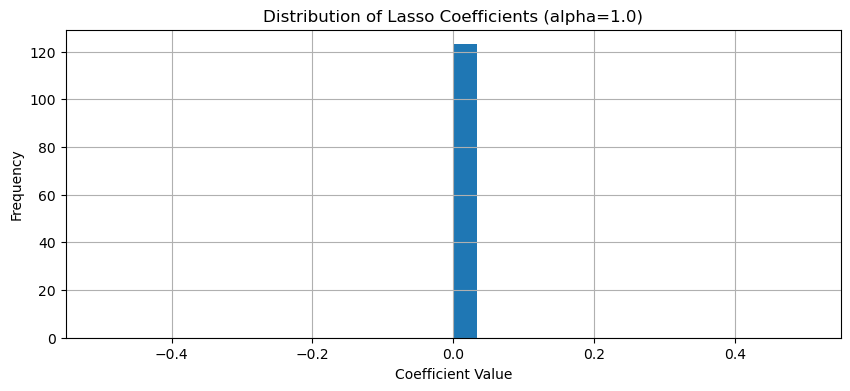

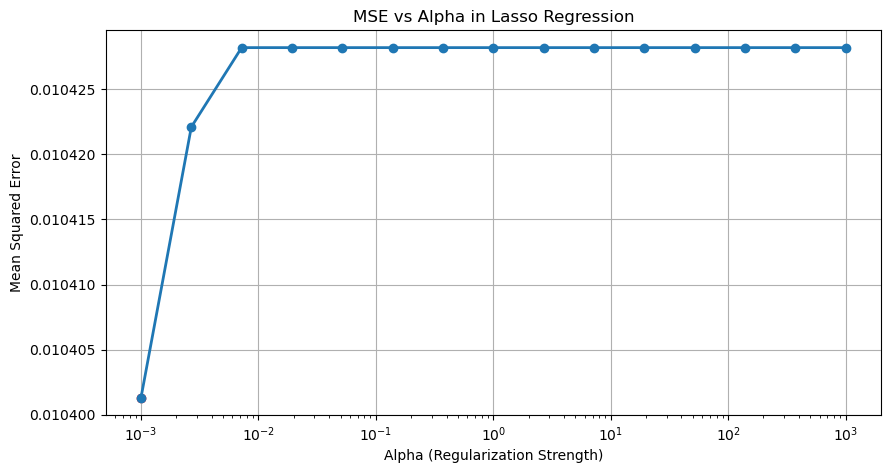

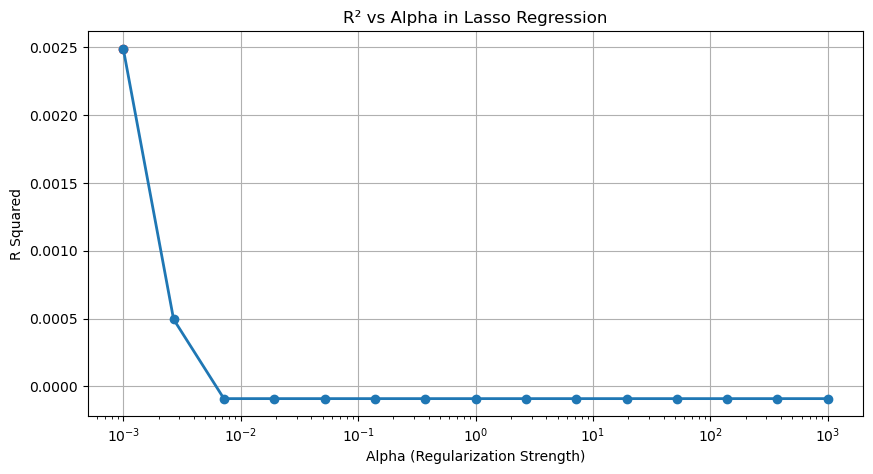

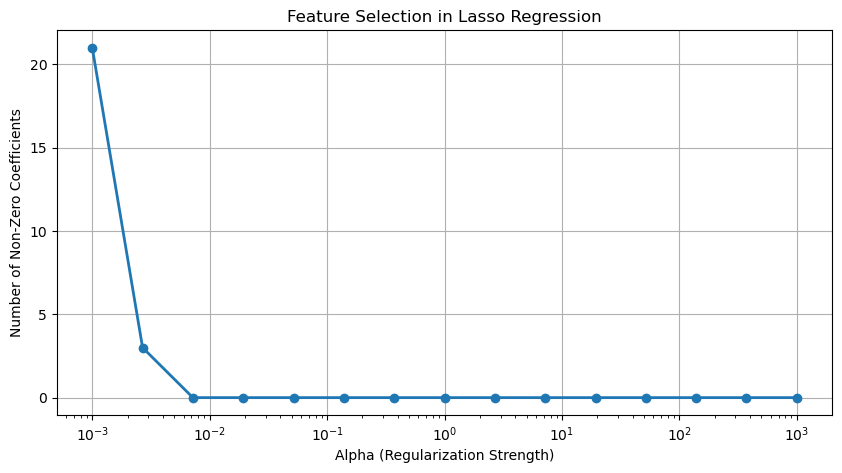

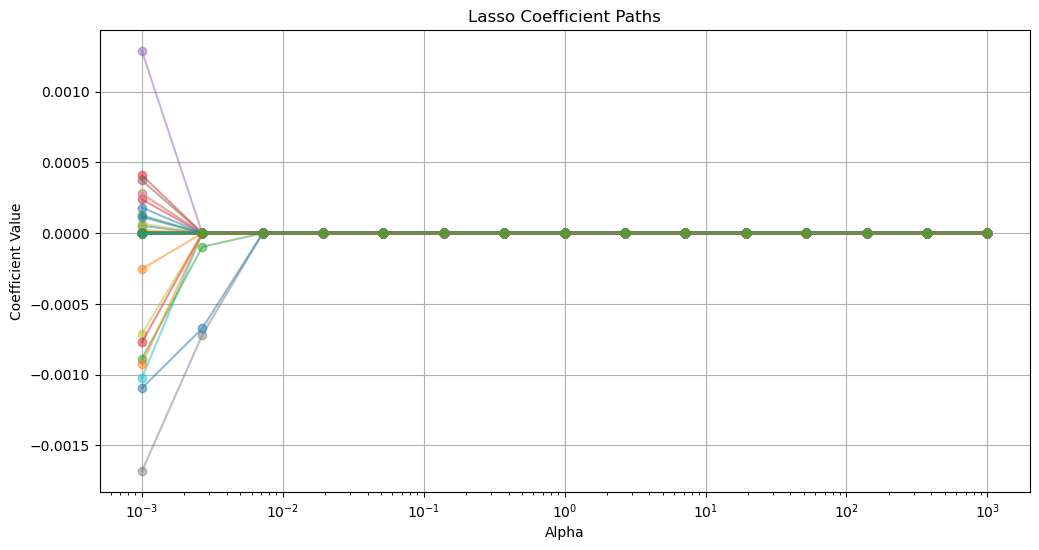

In [9]:
X_unscaled = df.drop(columns='ret')
X_unscaled = X_unscaled.apply(pd.to_numeric, errors='coerce')
X = (X_unscaled-X_unscaled.mean(axis=0))/X_unscaled.std(axis=0)
y = df['ret']
y = y.apply(pd.to_numeric, errors='coerce')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lasso regression with alpha=1.0
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)

# Compute and print MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Lasso Regression MSE (alpha=1.0): {mse:.4f}")

# Plot distribution of coefficients
plt.figure(figsize=(10, 4))
plt.hist(lasso.coef_, bins=30)
plt.title("Distribution of Lasso Coefficients (alpha=1.0)")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Analyze effect of varying alpha
alphas = np.logspace(-3, 3, 15)
coefs = []
mses = []
rs = []
nonzero_coefs = []  # Track number of non-zero coefficients

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)
    coefs.append(model.coef_)
    y_pred = model.predict(X_test)
    mses.append(mean_squared_error(y_test, y_pred))
    rs.append(r2_score(y_test, y_pred))
    nonzero_coefs.append(np.sum(model.coef_ != 0))  # Count non-zero coefficients

best_idx_ms = np.argmin(mses)
best_idx_rs = np.argmax(rs)  # Note: For R², we want maximum, not minimum
best_alpha_ms = alphas[best_idx_ms]
best_mse = mses[best_idx_ms]
best_alpha_rs = alphas[best_idx_rs]
best_rs = rs[best_idx_rs]

def plot(losses, best_loss, name_loss, abbrev, best_alpha, alphas):
    plt.figure(figsize=(10, 5))
    plt.plot(alphas, losses, marker='o', linewidth=2)
    plt.xscale("log")
    plt.xlabel("Alpha (Regularization Strength)")
    plt.ylabel(name_loss)
    plt.title(abbrev + " vs Alpha in Lasso Regression")
    plt.grid(True)
    # Turn off scientific notation
    plt.ticklabel_format(style='plain', axis='y')
    
    # Annotate best point
    plt.scatter(best_alpha, best_loss, color='red')
    
    plt.show()

plot(mses, best_mse, 'Mean Squared Error', 'MSE', best_alpha_ms, alphas)
plot(rs, best_rs, 'R Squared', 'R²', best_alpha_rs, alphas)

# Additional plot for feature selection behavior
plt.figure(figsize=(10, 5))
plt.plot(alphas, nonzero_coefs, marker='o', linewidth=2)
plt.xscale("log")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Number of Non-Zero Coefficients")
plt.title("Feature Selection in Lasso Regression")
plt.grid(True)
plt.show()

# Plot coefficient paths
plt.figure(figsize=(12, 6))
for i in range(len(coefs[0])):
    plt.plot(alphas, [coefs[j][i] for j in range(len(alphas))], 'o-', alpha=0.5)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths')
plt.grid(True)
plt.show()

Now compare with a manual Lasso regression

In [ ]:
def lasso_reg(X, y, alpha, max_iter=1000, tol=1e-4):
    """
    Lasso Regression Implementation using coordinate descent
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        Training data
    y : array-like, shape (n_samples,)
        Target values
    alpha : float
        Regularization strength (L1 penalty)
    max_iter : int, default=1000
        Maximum number of iterations
    tol : float, default=1e-4
        Tolerance for stopping criterion
        
    Returns:
    --------
    w : array, shape (n_features,)
        Coefficients
    """
    # Convert inputs to numpy arrays if they aren't already
    X = np.asarray(X)
    y = np.asarray(y)
    
    n_samples, n_features = X.shape
    
    # Initialize weights
    w = np.zeros(n_features)
    
    # Precompute X^T
    X_T = X.T
    
    # Precompute X^T * y
    Xy = np.dot(X_T, y)
    
    # Precompute X^T * X diagonal (for faster updates)
    X_squared = np.sum(X * X, axis=0)
    
    # Initialize prediction
    y_pred = np.zeros(n_samples)
    
    # Coordinate descent
    for iteration in range(max_iter):
        w_old = w.copy()
        
        # Update each coordinate
        for j in range(n_features):
            if X_squared[j] == 0:
                continue
                
            # Remove the contribution of feature j from the prediction
            y_pred -= w[j] * X[:, j]
            
            # Calculate the residual correlation
            r_j = Xy[j] - np.dot(X_T[j], y_pred)
            
            # Soft thresholding
            if r_j > alpha:
                w[j] = (r_j - alpha) / X_squared[j]
            elif r_j < -alpha:
                w[j] = (r_j + alpha) / X_squared[j]
            else:
                w[j] = 0
            
            # Update the prediction with the new weight
            y_pred += w[j] * X[:, j]
        
        # Check convergence
        if np.sum((w - w_old) ** 2) < tol:
            break
    
    return w


Predictors Function

In [2]:
def lasso_alphas_predictors(X_train, X_test, y_train, y_test):
    """
    Evaluate Lasso regression with different feature subsets and regularization parameters
    
    Parameters:
    -----------
    X_train : DataFrame
        Training features
    X_test : DataFrame
        Testing features
    y_train : Series
        Training target values
    y_test : Series
        Testing target values
        
    Returns:
    --------
    Plot of mean managed returns vs alpha for different feature subsets
    """
    subset_ratios = [0.1, 0.3, 0.5, 0.7, 1.0]  # Fractions of total features
    alphas = np.logspace(-4, 3, 20)
    results = {}
    
    for ratio in subset_ratios:
        num_features = int(X_train.shape[1] * ratio)
        selected_columns = np.random.choice(X_train.shape[1], num_features)
    
        avg_returns = []
        for alpha in alphas:
            # For Lasso, we don't need the trick parameter
            w = lasso_reg(X_train.iloc[:, selected_columns].values, y_train.values, alpha)
            y_pred = X_test.iloc[:, selected_columns].values @ w
            managed_returns = y_pred * y_test.values
            avg_return = managed_returns.mean()
            avg_returns.append(avg_return)
    
        results[f"{int(ratio * 100)}% features"] = avg_returns
    
    # Plot the "Mean Return vs Alpha" curves in subplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
    axes = axes.flatten()
    
    for i, (label, avg_returns) in enumerate(results.items()):
        axes[i].plot(alphas, avg_returns, marker='o')
        axes[i].set_title(label)
        axes[i].set_xscale('log')
        axes[i].set_xlabel("Alpha")
        axes[i].set_ylabel("Mean Return")
        axes[i].grid(True)
    
    # Hide unused subplot if subset count < total axes
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle("Mean Managed Return vs Alpha for Different Predictor Subsets (Lasso)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

Cross Validation

In [3]:
def nested_cv_lasso(X, y, alphas, outer_splits=5, inner_splits=3, random_state=42):
    """
    Nested cross-validation for Lasso regression
    
    Parameters:
    -----------
    X : DataFrame
        Features
    y : Series
        Target values
    alphas : list
        List of alpha values to try
    outer_splits : int, default=5
        Number of outer CV splits
    inner_splits : int, default=3
        Number of inner CV splits
    random_state : int, default=42
        Random seed for reproducibility
        
    Returns:
    --------
    selected_alphas : list
        Selected alpha for each outer fold
    all_outer_scores : list
        MSE scores for each outer fold
    """
    from sklearn.linear_model import Lasso
    from sklearn.model_selection import KFold
    from sklearn.metrics import mean_squared_error
    
    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    all_outer_scores = []
    selected_alphas = []

    for train_idx, test_idx in outer_cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Inner CV to select best alpha
        inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=random_state)
        inner_scores = []

        for alpha in alphas:
            fold_scores = []
            for inner_train_idx, val_idx in inner_cv.split(X_train):
                X_inner_train, X_val = X_train.iloc[inner_train_idx], X_train.iloc[val_idx]
                y_inner_train, y_val = y_train.iloc[inner_train_idx], y_train.iloc[val_idx]

                # Use sklearn's Lasso for stability
                model = Lasso(alpha=alpha, max_iter=10000, tol=1e-4)
                model.fit(X_inner_train, y_inner_train)
                y_pred = model.predict(X_val)
                score = mean_squared_error(y_val, y_pred)
                fold_scores.append(score)

            avg_score = np.mean(fold_scores)
            inner_scores.append((alpha, avg_score))

        # Select best alpha from inner CV
        best_alpha = min(inner_scores, key=lambda x: x[1])[0]
        selected_alphas.append(best_alpha)

        # Retrain on full training set with best alpha
        final_model = Lasso(alpha=best_alpha, max_iter=10000, tol=1e-4)
        final_model.fit(X_train, y_train)
        y_final_pred = final_model.predict(X_test)
        outer_score = mean_squared_error(y_test, y_final_pred)
        all_outer_scores.append(outer_score)

    return selected_alphas, all_outer_scores

Rolling Cross validation

In [4]:
def rolling_lasso_cv(X, y, alphas, window_size=100, overlap=False):
    """
    Rolling window cross-validation for Lasso regression
    
    Parameters:
    -----------
    X : DataFrame
        Features (standardized and cleaned)
    y : Series
        Target variable
    alphas : list
        List of regularization strengths to try
    window_size : int, default=100
        Size of the training window
    overlap : bool, default=False
        Whether test sets should overlap
        
    Returns:
    --------
    alpha_results : list
        Best alpha for each window
    y_tests : list
        Actual test values for each window
    y_preds : list
        Predicted values for each window
    scores : list
        MSE scores for each window
    """
    from sklearn.linear_model import Lasso
    from sklearn.metrics import mean_squared_error
    
    test_size = int(window_size * 0.3)
    n = X.shape[0]
    y = y[:n]
    step = 1 if overlap else test_size
    alpha_results = []
    y_preds = []
    y_tests = []
    scores = []

    for start in range(0, n - n%(window_size + step) - 1, window_size + step):
        
        X_train = X.iloc[start:start + window_size]
        y_train = y.iloc[start:start + window_size]
        X_test = X.iloc[start + window_size:start + window_size + step]
        y_test = y.iloc[start + window_size:start + window_size + step]

        best_alpha = None
        best_score = float('inf')
        mini_y_pred = []
        mini_score = []
        mini_y_test = []

        for alpha in alphas:
            # Use sklearn's Lasso for stability
            model = Lasso(alpha=alpha, max_iter=10000, tol=1e-4)
            try:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                mini_y_pred.append(y_pred)
                score = mean_squared_error(y_test, y_pred)
                mini_y_test.append(y_test)
                mini_score.append(score)

                if score < best_score:
                    best_score = score
                    best_alpha = alpha

            except Exception as e:
                print(f"\n Error during fit at iteration starting at index {start}")
                print(f"Alpha: {alpha}")
                print(f"X_train shape: {X_train.shape}")
                print(f"y_train shape: {y_train.shape}")
                print(f"X_test shape: {X_test.shape}")
                print(f"y_test shape: {y_test.shape}")
                print("Exception message:", str(e))
                continue  
            
        alpha_results.append(best_alpha)
        if start%(20*(window_size+step)) == 0:
            print(start)

        y_preds.append(mini_y_pred)
        scores.append(mini_score)
        y_tests.append(mini_y_test)

    return alpha_results, y_tests, y_preds, scores

Useage

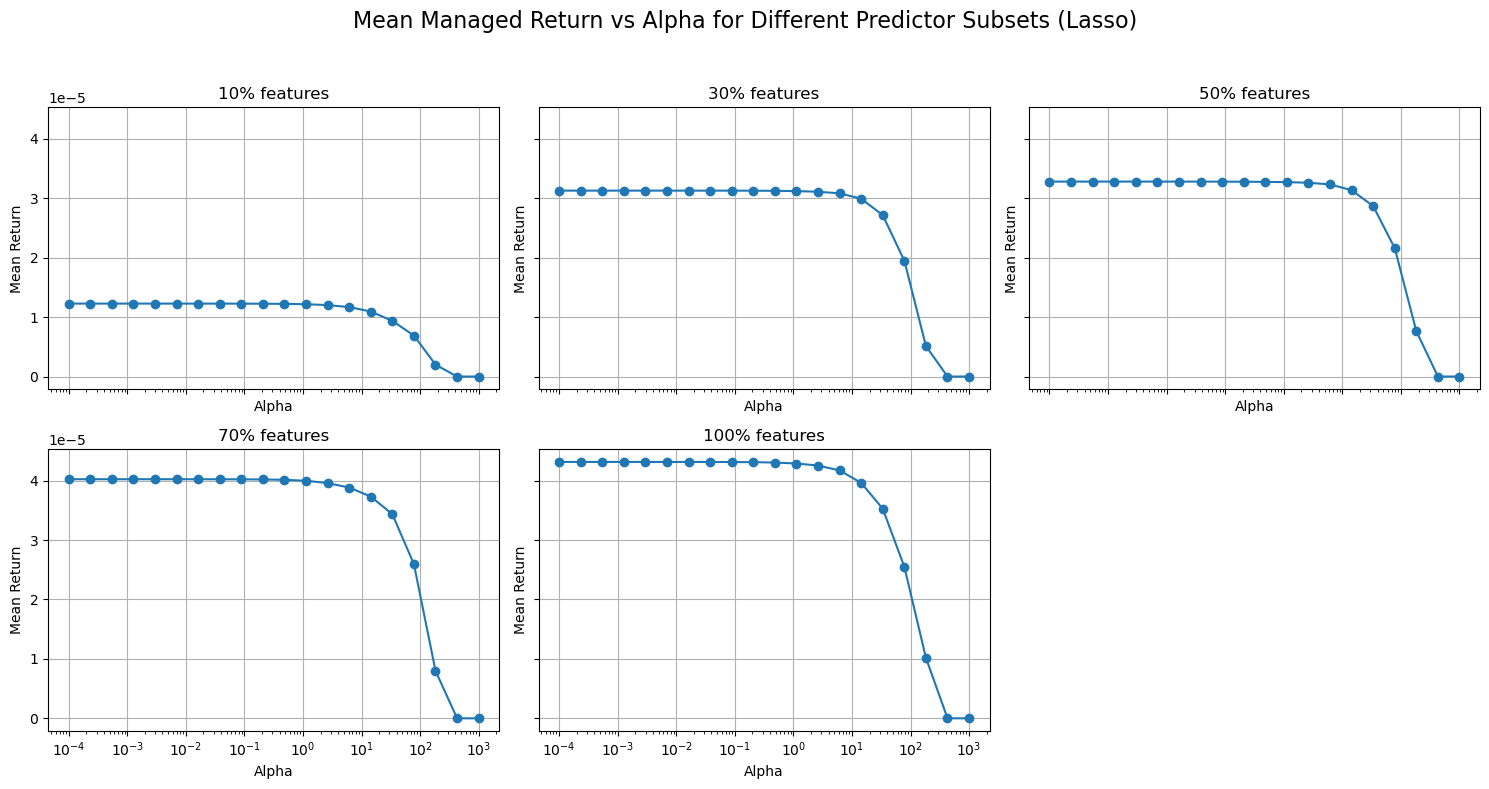

Selected alphas: [0.00023357214690901214, 0.00023357214690901214, 0.00023357214690901214, 0.0001, 0.00023357214690901214]
Mean outer score: 0.010025096393539535


/home/Loris/miniconda3/envs/MLFIN/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.428e-03, tolerance: 7.538e-05
  model = cd_fast.enet_coordinate_descent(
/home/Loris/miniconda3/envs/MLFIN/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.226e-04, tolerance: 7.538e-05
  model = cd_fast.enet_coordinate_descent(


0


/home/Loris/miniconda3/envs/MLFIN/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.195e-03, tolerance: 4.499e-05
  model = cd_fast.enet_coordinate_descent(
/home/Loris/miniconda3/envs/MLFIN/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.757e-03, tolerance: 5.065e-05
  model = cd_fast.enet_coordinate_descent(
/home/Loris/miniconda3/envs/MLFIN/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

2600


...

111800


/home/Loris/miniconda3/envs/MLFIN/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.603e-04, tolerance: 1.210e-04
  model = cd_fast.enet_coordinate_descent(


114400


/home/Loris/miniconda3/envs/MLFIN/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.075e-05, tolerance: 4.109e-05
  model = cd_fast.enet_coordinate_descent(
/home/Loris/miniconda3/envs/MLFIN/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.036e-04, tolerance: 6.342e-05
  model = cd_fast.enet_coordinate_descent(
/home/Loris/miniconda3/envs/MLFIN/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

117000
119600
122200


In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Lasso

# Example usage
X_unscaled = df.drop(columns='ret')
X_unscaled = X_unscaled.apply(pd.to_numeric, errors='coerce')
X = (X_unscaled-X_unscaled.mean(axis=0))/X_unscaled.std(axis=0)

y = df['ret']
y = y.apply(pd.to_numeric, errors='coerce')

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Run Lasso with different feature subsets
lasso_alphas_predictors(X_train, X_test, y_train, y_test)

# Nested cross-validation
alphas = np.logspace(-4, 3, 20)
selected_alphas, outer_scores = nested_cv_lasso(X, y, alphas)
print(f"Selected alphas: {selected_alphas}")
print(f"Mean outer score: {np.mean(outer_scores)}")

# Rolling window cross-validation
alpha_results, y_tests, y_preds, scores = rolling_lasso_cv(X, y, alphas)